In [55]:
! pip install numpy
! pip install matplotlib
! pip install pandas
! pip install scipy
! pip install statsmodels
! pip install seaborn


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)

[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip


# Todo
- check whether people reuse names in rounds 1-3, so that round 4 they would have an expectation of success in reuse but then don't get it.
- check what happens if we average the submission times and only have one result per group


In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import re
import glob

# Processing pipeline (for supplement)

1. Load all `revision_202509/batch_*.scienceData.jsonl` records with `sampleId != "missing"`.
2. Extract treatment condition, game identifiers, connection/browser metadata, QC responses, and stage submission times.
3. For labeling stages, use submit-button timestamps; if missing (auto-advance), set labeling time to 300 seconds (5-minute timeout).
4. Parse recall prompts, lowercase/strip responses, and compute per-image matches only when both partners responded identically.
5. Score each round as 10 points per unique matched label (to discourage repeating a single label).
6. Exclude participants with `num_reports >= 3` or near-complete nonresponse in recall (`empty_recall_counts >= 10`).
7. Aggregate to the game (pair) level: one row per game/treatment; use the max labeling time across partners; keep points (identical within pairs).
8. Primary prereg outcomes: round 3 labeling time (seconds) and round 4 accuracy (points), using only `schema` and `nonschema`.


In [2]:
# read science data line by line, parse json, and store in a list
# filename = 'batch_20240409_1520_turkPilot.scienceData.jsonl'
# filename = 'batch_20240410_1435_turkPilot2.scienceData.jsonl'
# filename = 'revision_202504/batch_20250421_1915_pilot.scienceData.jsonl'
# filename = 'revision_202504/batch_20250429_1536_pilot.scienceData.jsonl'
# filename = 'revision_202508/batch_20250903_1711_pilot.scienceData.jsonl'
# filename = 'revision_202509/batch_20250915_2010_pilot.scienceData.jsonl'
# filename = 'revision_202509/batch_20251006_1952_pilot.scienceData.jsonl'
# filenames = [
#     'revision_202509/batch_20250915_2010_pilot.scienceData.jsonl',
#     'revision_202509/batch_20251006_1952_pilot.scienceData.jsonl',
#     'revision_202509/batch_20251105_1931_pilot.scienceData.jsonl'
# ]
filenames = glob.glob('revision_202509/batch_*.scienceData.jsonl')
print("Filenames to process:", filenames)
raw = []

for filename in filenames:
    with open(filename) as f:
        for line in f:
            parsed = json.loads(line)
            if parsed['sampleId'] != 'missing':
                raw.append(parsed)


all_data = pd.DataFrame()
all_data["treatment"] = [row["treatment"]["name"] for row in raw]
all_data["treatmentGroup"] = [row["treatment"]["name"].split("_")[0] for row in raw]
all_data["sampleId"] = [row["sampleId"] for row in raw]
all_data["gameId"] = [row["gameId"][-6:] for row in raw]
all_data["gameId_full"] = [row["gameId"] for row in raw]

# sanity check: truncated gameId is unique in this dataset
_gameid_collisions = all_data.groupby("gameId")["gameId_full"].nunique()
assert _gameid_collisions.max() == 1, f"Truncated gameId collision(s): {_gameid_collisions[_gameid_collisions > 1].index.tolist()}"

# parse connection info into columns
connection_info = pd.DataFrame([row['connectionInfo'] for row in raw])
all_data = pd.concat([all_data, connection_info], axis=1)

# Parse browser info into columns
browser_info = pd.DataFrame([row['browserInfo'] for row in raw])
all_data = pd.concat([all_data, browser_info], axis=1)

# Parse QC survey into columns
QC = pd.DataFrame([(row['QCSurvey']['responses'] if row['QCSurvey'] != "missing" else {}) for row in raw])
all_data = pd.concat([all_data, QC], axis=1)

# Parse participation data into columns
all_data["num_reports"] = [len(row["reports"]) for row in raw]

# parse labeling submission times into columns
# these are taken from the submit button timings
submit_times = pd.DataFrame([{k: v['time'] for k, v in row['stageSubmissions'].items()} for row in raw])
columns = ["time_"+"_".join(col.replace("submitButton_", "").split("_")[-3:]) for col in submit_times.columns]
submit_times.columns = columns
submit_times = submit_times[sorted(submit_times.columns)]

labeling_times = [col for col in submit_times.columns if "labeling" in col]
missing_labeling_counts = submit_times[labeling_times].isna().sum()
print("Missing labeling times (count before timeout fill):", missing_labeling_counts.to_dict())
submit_times[labeling_times] = submit_times[labeling_times].fillna(300) # fill missing labeling times with 5 minutes, the max
assert submit_times[labeling_times].isna().sum().sum() == 0

all_data = pd.concat([all_data, submit_times[labeling_times]], axis=1)

# # parse labels into columns
# def extract_word(cell):
#     for i in range(8):
#         cell = cell.replace(f"Image {i+1}:", "")
#     return cell.strip()

# def get_labels(row):
#     keys = ['prompt_labeling_1a', 'prompt_labeling_1b', 'prompt_labeling_1c',
#             'prompt_labeling_2', 'prompt_labeling_3', 'prompt_labeling_4']
#     labels = {}
#     for key in keys:
#         try:
#             raw_labels_for_round = row['prompts'][key]['value'].split("\n")
#             raw_labels_for_round = [extract_word(label) for label in raw_labels_for_round]
#             for i, word in enumerate(raw_labels_for_round):
#                 labels[key.replace("prompt_labeling_", "label_") + "_" + str(i)] = word
#         except (KeyError, TypeError, AttributeError):
#             continue

#     return labels
    
# labels = pd.DataFrame([get_labels(row) for row in raw])
# labels = labels[sorted(labels.columns)]
# all_data = pd.concat([all_data, labels], axis=1)

# Parse recall responses into columns
# standardize recall responses to lowercase and strip leading and trailing whitespace
recall = pd.DataFrame([{key: d['value'].lower().strip() for key, d in row['prompts'].items() if 'recall' in key} for row in raw])
recall.columns = [col.replace('prompt_recall_', 'recall_') for col in recall.columns]
recall = recall[sorted(recall.columns)].fillna("") # fill missing recall responses with empty string
expected_recall_counts = {"1a": 2, "1b": 4, "1c": 8, "2": 8, "3": 8, "4": 8}
observed_rounds = {col.split("_")[1] for col in recall.columns}
assert observed_rounds == set(expected_recall_counts), f"Unexpected recall rounds: {observed_rounds}"
observed_recall_counts = {round_key: sum(col.split("_")[1] == round_key for col in recall.columns) for round_key in expected_recall_counts}
assert observed_recall_counts == expected_recall_counts, f"Recall column mismatch: {observed_recall_counts}"
all_data = pd.concat([all_data, recall], axis=1)

# # Compute total recall time
# total_recall_time = pd.DataFrame()
# for round in sorted(set([col.split("_")[1] for col in recall.columns])):
#     cols = [col for col in all_data.columns if "time_recall_"+round in col]
#     total_recall_time["time_recall_total_"+round] = all_data[cols].sum(axis=1)

# all_data = pd.concat([all_data, total_recall_time], axis=1)

# Compute matches (true/false) and merge into columns
matches = (all_data.groupby("gameId")[recall.columns].nunique() == 1) & (all_data.groupby("gameId")[recall.columns].count() == 2)  # binary did they match, and did they both participate?
matches.columns = [col.replace("recall_", "match_") for col in matches.columns]
all_data = pd.merge(left=all_data, right=matches, left_on="gameId", right_index=True)

# # Compute raw points and merge into columns (not used in the final analysis)
# points = pd.DataFrame()
# for round in sorted(set([col.split("_")[1] for col in matches.columns])):
#     cols_in_round = [col for col in  matches.columns if f"_{round}_" in col]
#     points["points_"+round] = matches[cols_in_round].sum(axis=1)*10 # each correct recall is worth 10 points
# all_data = pd.merge(left=all_data, right=points, left_on="gameId", right_index=True)

# find matched recalls (i.e., the actual words that were recalled the same)
matched_recalls = pd.DataFrame()
for match_col in [col for col in all_data.columns if "match_" in col]:
    recall_col = match_col.replace("match_", "recall_")
    matched_recall_col = match_col.replace("match_", "matched_recall_")
    all_data[matched_recall_col] = all_data[recall_col]*all_data[match_col] # mask out non-matches (they are empty strings)


# compute points only on unique labels
points_unique = pd.DataFrame()
for round in ["1a", "1b", "1c", "2", "3", "4"]:
    cols = [col for col in  all_data if f"matched_recall_{round}_" in col]
    all_data[f"points_unique_{round}"] = all_data[cols].replace("", np.nan).nunique(axis=1) * 10 # each correct recall is worth 10 points, don't count empty stings

# # # compute scores excluding recall time
# for round in sorted(set([col.split("_")[1] for col in matches.columns])):
#     all_data[f"score_{round}"] = (all_data["points_unique_"+round] / all_data["time_labeling_"+round] * 60).round(2)  # score is points earned per minute of coordination time


# # # compute scores including recall time
# # scores_with_recall = pd.DataFrame()
# # for round in sorted(set([col.split("_")[1] for col in matches.columns])):
# #     total_time = all_data["time_labeling_"+round] + all_data["time_recall_total_"+round]
# #     scores_with_recall["score_with_recall_"+round] = (all_data["points_unique_"+round] / total_time * 60).round(2)  # score is points earned per minute of total time

# # all_data = pd.concat([all_data, scores_with_recall], axis=1)

# # sort all_data for easier viewing
# all_data = all_data.sort_values(by=['treatmentGroup', 'treatment', 'gameId']).reset_index(drop=True)


# filter groups with nonparticipation
all_data = all_data[all_data["num_reports"]<3]  # not missing from conversation
participant_counts = all_data.groupby("gameId")["sampleId"].nunique()
assert participant_counts.max() <= 2, "More than two participants found for a gameId"
print("Participants per gameId:", participant_counts.value_counts().to_dict())
treatment_counts = all_data.groupby("gameId")["treatment"].nunique()
assert treatment_counts.max() == 1, "Mixed treatments within a gameId"
all_data['empty_recall_counts'] = (all_data[[col for col in  recall.columns]] == "").sum(axis=1)
all_data = all_data[all_data['empty_recall_counts'] < 10]  # participating in recall

print("condition counts:", all_data.groupby("treatment")["sampleId"].count())

all_data.to_csv("pilot_analysis_results.csv", index=False)

pd.options.display.max_rows = None
print(all_data.shape)

#all_data[all_data["gameId"] == raw[0]["gameId"][-6:]].T

use_conditions = ['schema', 'nonschema']
all_data[all_data["treatment"].isin(use_conditions)].sort_values(by=['treatmentGroup', 'treatment', 'gameId']).T


Filenames to process: ['revision_202509/batch_20251209_1551_pilot.scienceData.jsonl', 'revision_202509/batch_20251209_1914_pilot.scienceData.jsonl', 'revision_202509/batch_20251105_1931_pilot.scienceData.jsonl', 'revision_202509/batch_20260106_2205_pilot.scienceData.jsonl', 'revision_202509/batch_20250915_2010_pilot.scienceData.jsonl', 'revision_202509/batch_20251006_1952_pilot.scienceData.jsonl', 'revision_202509/batch_20251006_1941_pilot.scienceData.jsonl', 'revision_202509/batch_20250915_2325_pilot.scienceData.jsonl']
Missing labeling times (count before timeout fill): {'time_labeling_1a': 8, 'time_labeling_1b': 8, 'time_labeling_1c': 27, 'time_labeling_2': 26, 'time_labeling_3': 15, 'time_labeling_4': 37}
Participants per gameId: {2: 62, 1: 4}
condition counts: treatment
nonschema                    29
nonschema_black_and_white    16
nonschema_tangrams            8
schema                       28
schema_black_and_white       16
schema_nonschema              6
schema_tangrams       

,16,17,57,58,95,98,82,83,44,46,...,51,54,59,64,80,81,75,77,71,72
treatment,nonschema,nonschema,nonschema,nonschema,nonschema,nonschema,nonschema,nonschema,nonschema,nonschema,...,schema,schema,schema,schema,schema,schema,schema,schema,schema,schema
treatmentGroup,nonschema,nonschema,nonschema,nonschema,nonschema,nonschema,nonschema,nonschema,nonschema,nonschema,...,schema,schema,schema,schema,schema,schema,schema,schema,schema,schema
sampleId,37837561-9529-477a-b8dd-f641f8765e4d,bd4e3570-652a-4e1f-8643-6719eb6a9c38,2854f232-4ea1-4eea-9a5c-404bbb3102e9,9f738f00-cff6-410a-85d8-da36b5c4764f,d1e7143f-4864-4498-843f-196820730bf4,d4c3cc1c-1171-4c7a-bd36-95b1d787300b,c88d0313-17ed-46c1-b71a-497216a266d2,43bc610d-8a32-4d94-814a-767a03aaa55e,9c11532a-270d-453a-bf01-54996b269071,08d18631-d4d8-4f0d-b566-2cb573b3159f,...,42ffb7f2-e462-4ce6-83d1-9b7b32e6702e,2a635e23-ab9a-4e33-bb89-0c60f816497f,35cb2f4e-0c74-4185-9826-d48743ba896f,29d82a96-503c-497f-a047-0abaac9b3271,0204802a-f5dd-4407-b84f-47eb858af386,588b9075-89b7-4e48-a950-716980a73141,b1d2fffe-fa95-4b4f-815e-a11c8f5ff99b,5f4bcd54-144e-488d-abb9-9116dc8d5745,9c65043d-ad4f-4189-a0c7-0086fec80922,aa4497b2-a98b-416e-8c1d-5d53fdc80914
gameId,ACFAK0,ACFAK0,B78GBJ,B78GBJ,C3XTXF,C3XTXF,CHGNHQ,CHGNHQ,D98JZ6,D98JZ6,...,JBMYEM,JBMYEM,KH7MPC,KH7MPC,PWNDE7,PWNDE7,RRAMXF,RRAMXF,VD27WJ,VD27WJ
gameId_full,01KC297CH9NF928CTKQ7ACFAK0,01KC297CH9NF928CTKQ7ACFAK0,01KEAQV21AD97VYQV6PMB78GBJ,01KEAQV21AD97VYQV6PMB78GBJ,01K57J8AM4ZSYG7DRS7BC3XTXF,01K57J8AM4ZSYG7DRS7BC3XTXF,01KEAVXJHTQ7X4YK4WBVCHGNHQ,01KEAVXJHTQ7X4YK4WBVCHGNHQ,01KEANZPRGA7CFP4MJ9YD98JZ6,01KEANZPRGA7CFP4MJ9YD98JZ6,...,01KEAP791GKG1EATYAZ5JBMYEM,01KEAP791GKG1EATYAZ5JBMYEM,01KEAR3DT79WBTVVFK6VKH7MPC,01KEAR3DT79WBTVVFK6VKH7MPC,01KEATRS3SXFQMKH0SSZPWNDE7,01KEATRS3SXFQMKH0SSZPWNDE7,01KEATEXXXAY3X3NCWQ9RRAMXF,01KEATEXXXAY3X3NCWQ9RRAMXF,01KEAT8B0NAZ6J2DE6D6VD27WJ,01KEAT8B0NAZ6J2DE6D6VD27WJ
country,US,GB,US,US,GB,GB,US,US,US,GB,...,CA,GB,GB,GB,CA,US,GB,US,CA,GB
timezone,America/Los_Angeles,Europe/London,America/Chicago,America/New_York,Europe/London,Europe/London,America/Los_Angeles,America/New_York,America/New_York,Europe/London,...,America/Vancouver,Europe/London,Europe/London,Europe/London,America/Toronto,America/New_York,Europe/London,America/New_York,America/Vancouver,Europe/London
isKnownVpn,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
timezoneOffset,-08:00,+00:00,-06:00,-05:00,+01:00,+01:00,-08:00,-05:00,-05:00,+00:00,...,-08:00,+00:00,+00:00,+00:00,-05:00,-05:00,+00:00,-05:00,-08:00,+00:00
isLikelyVpn,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,True,True,False,True,True,False


In [24]:
# pull out just the data we care about

data = all_data[[
    "treatment", "gameId", 
    "points_unique_1a", "points_unique_1b", "points_unique_1c", "points_unique_2", "points_unique_3", "points_unique_4", 
    "time_labeling_1a", "time_labeling_1b", "time_labeling_1c", "time_labeling_2", "time_labeling_3", "time_labeling_4"
]]
points_cols = [col for col in data.columns if col.startswith("points_unique_")]
assert data.groupby(["treatment","gameId"])[points_cols].std().max().max() == 0 # check that points are the same within each gameId

# find out pairs that have both partners with responses
pairs = (data.groupby(["treatment","gameId"])[["points_unique_3", "points_unique_4"]].count() == 2)



data = data.groupby(["treatment","gameId"]).max()  # use the max submission time in the group (this does nothing to points since they are the same within each group)
# recompute score based on max time 
data["score_1a"] = data["points_unique_1a"] / data["time_labeling_1a"] * 60 
data["score_1b"] = data["points_unique_1b"] / data["time_labeling_1b"] * 60 
data["score_1c"] = data["points_unique_1c"] / data["time_labeling_1c"] * 60 
data["score_2"] = data["points_unique_2"] / data["time_labeling_2"] * 60 
data["score_3"] = data["points_unique_3"] / data["time_labeling_3"] * 60 
data["score_4"] = data["points_unique_4"] / data["time_labeling_4"] * 60

data = data.loc[pairs[pairs.all(axis=1)].index]

data.reset_index(inplace=True)

data


,treatment,gameId,points_unique_1a,points_unique_1b,points_unique_1c,points_unique_2,points_unique_3,points_unique_4,time_labeling_1a,time_labeling_1b,time_labeling_1c,time_labeling_2,time_labeling_3,time_labeling_4,score_1a,score_1b,score_1c,score_2,score_3,score_4
0,nonschema,ACFAK0,20,40,80,60,80,50,144.458,151.970,117.963,300.000,237.384,274.837,8.306913,15.792591,40.690725,12.000000,20.220402,10.915561
1,nonschema,B78GBJ,20,40,80,70,70,80,74.549,79.479,116.520,151.513,141.194,134.407,16.096795,30.196656,41.194645,27.720394,29.746307,35.712426
2,nonschema,C3XTXF,20,30,70,80,70,60,104.590,65.860,85.685,120.405,154.941,109.179,11.473372,27.330701,49.016747,39.865454,27.107092,32.973374
3,nonschema,CHGNHQ,20,40,80,80,80,70,66.092,217.472,96.382,274.077,239.301,271.287,18.156509,11.035903,49.801830,17.513327,20.058420,15.481759
4,nonschema,D98JZ6,20,30,70,50,60,40,49.953,54.137,59.905,80.960,111.895,66.830,24.022581,33.248979,70.111009,37.055336,32.173019,35.912016
5,nonschema,G2P3DH,20,40,80,80,80,80,55.344,69.838,123.338,297.160,219.858,202.901,21.682567,34.365245,38.917446,16.152914,21.832274,23.656857
6,nonschema,GMAZT0,20,30,80,80,80,80,100.403,101.768,99.594,172.941,181.248,198.304,11.951834,17.687289,48.195674,27.755130,26.483051,24.205261
7,nonschema,H72RRV,20,40,70,80,80,80,40.652,38.830,104.025,239.695,221.230,241.100,29.518843,61.807881,40.374910,20.025449,21.696877,19.908752
8,nonschema,HNH7HQ,20,40,70,80,70,80,52.730,66.159,97.010,129.480,126.623,108.657,22.757444,36.276244,43.294506,37.071362,33.169329,44.175709
9,nonschema,MQFV0D,10,40,70,80,80,80,96.442,69.995,103.048,274.656,299.532,300.000,6.221356,34.288163,40.757705,17.476407,16.024999,16.000000


In [25]:
data.groupby("treatment")[["points_unique_3", "points_unique_4", "time_labeling_3", "time_labeling_4", "score_3", "score_4"]].mean().loc[['nonschema', 'schema']]

,points_unique_3,points_unique_4,time_labeling_3,time_labeling_4,score_3,score_4
treatment,,,,,,
nonschema,74.285714,72.142857,197.839071,204.459286,23.908489,24.259049
schema,72.142857,47.857143,133.287500,191.118786,37.002517,17.801925


In [26]:
data.groupby("treatment")[["score_3", "score_4"]].count().loc[['nonschema', 'schema']]

,score_3,score_4
treatment,,
nonschema,14,14
schema,14,14


/var/folders/2l/3kmvzs0s1sggnw_9sl0ls8080000gn/T/ipykernel_21104/3567621271.py:23: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  QC["videoQuality"].replace("NA", np.nan).astype(float).value_counts().sort_index().plot(kind='bar', title="Video Quality")


Comments:
Participating in this study was super fun!
Thanks for the opportunity to participate in this study!
No
Nothing
no comment
my partner was very nice.
no
N/A
really enjoyable interesting study
no thank you
it was enjoyable
none
It was great fun!
no
I was the only doing this the person showed for a minute and never come back
no
I did not encounter technical problem during the experiment. 
I overthink things, so the instructions were probably easy, I just got hung up on the part about whether we allowed to reuse the same labels for different objects across rounds (I thought we could reuse them as long as it was not in the same round but thought it would be too confusing to use the same label for different objects, so we decided not to, or at least I said I preferred not to because I would likely confuse them.)
This was a lot of fun!
No
none
n/a
The research was very interesting, but it took much longer than expected.
No, thank you for letting me participate
My partner Nelson compl

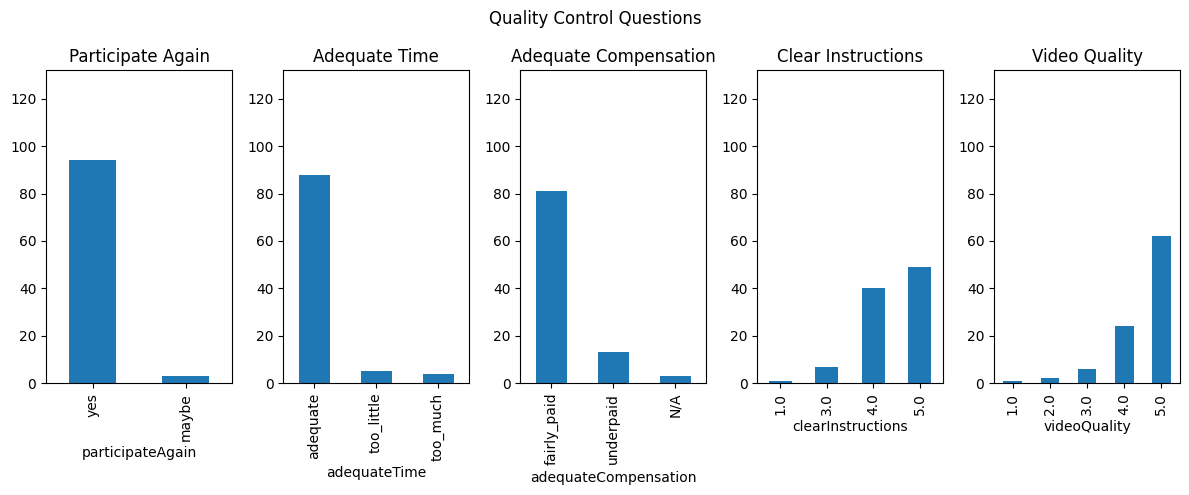

In [27]:
# Plot QC data

plt.figure(figsize=(12, 5))
plt.subplot(1,5,1)
QC["participateAgain"].value_counts().plot(kind='bar', title="Participate Again")
plt.ylim(0, len(QC))

plt.subplot(1,5,2)
# QC["adequateTime"].value_counts().loc[["too_little", "adequate", "too_much"]].plot(kind='bar', title="Adequate Time")
QC["adequateTime"].value_counts().plot(kind='bar', title="Adequate Time")
plt.ylim(0, len(QC))

plt.subplot(1,5,3)
QC["adequateCompensation"].value_counts().plot(kind='bar', title="Adequate Compensation")
plt.ylim(0, len(QC))

plt.subplot(1,5,4)
QC["clearInstructions"].value_counts().sort_index().plot(kind='bar', title="Clear Instructions")
plt.ylabel('')
plt.ylim(0, len(QC))

plt.subplot(1,5,5)
QC["videoQuality"].replace("NA", np.nan).astype(float).value_counts().sort_index().plot(kind='bar', title="Video Quality")
plt.ylabel('')
plt.ylim(0, len(QC))

plt.suptitle("Quality Control Questions")
plt.tight_layout()

print("Comments:")
for text in QC["textExpansion"]:
    if str(text) != "nan":
        print(text)

print("\nTechnical Issues:")
for text in QC["textExpansion"]:
    if str(text) != "nan":
        print(text)


# QC

# Power Calculations

### Round 3

In [28]:

# grouped_3 = data.groupby("treatmentGroup") # use all data for round 3 analysis
grouped_3 = data[data["treatment"].isin(["schema", "nonschema"])].groupby("treatment")
means_3 = grouped_3[["points_unique_3", "time_labeling_3",  "score_3"]].mean()
sds_3 = grouped_3[["points_unique_3", "time_labeling_3", "score_3"]].std()
ns_3 = grouped_3[["points_unique_3", "time_labeling_3", "score_3"]].count()

means_3

,points_unique_3,time_labeling_3,score_3
treatment,,,
nonschema,74.285714,197.839071,23.908489
schema,72.142857,133.287500,37.002517


In [29]:
means_3.diff()

,points_unique_3,time_labeling_3,score_3
treatment,,,
nonschema,NaN,NaN,NaN
schema,-2.142857,-64.551571,13.094028


In [30]:
def pooled_sd(s1, s2, n1, n2):
    return np.sqrt(((n1 - 1)*s1**2 + (n2 - 1)*s2**2) / (n1 + n2 - 2))

pooled_sds_3 = pd.DataFrame({col: pooled_sd(sds_3.loc["nonschema"][col], sds_3.loc["schema"][col], ns_3.loc["nonschema"][col], ns_3.loc["schema"][col]) for col in means_3.columns}, index=[0])
pooled_sds_3


,points_unique_3,time_labeling_3,score_3
0,9.958706,50.237545,12.34804


In [31]:
# Calculate effect size for each metric
effect_sizes_3 = (means_3.loc["schema"] - means_3.loc["nonschema"]) / pooled_sds_3
effect_sizes_3

,points_unique_3,time_labeling_3,score_3
0,-0.215174,-1.284927,1.060413


In [32]:
# calculate required sample size for power for each metric
from statsmodels.stats.power import TTestIndPower
alpha = 0.025
desired_power = 0.9
power_analysis = TTestIndPower()
power_results = pd.DataFrame({col: power_analysis.solve_power(effect_size=effect_sizes_3[col][0], alpha=alpha, power=desired_power) for col in effect_sizes_3.columns}, index=[0])
power_results

,points_unique_3,time_labeling_3,score_3
0,537.379903,16.365599,23.382701


### Round 4

In [33]:
# use all data for round 3 analysis
grouped_4 = data[data["treatment"].isin(["schema", "nonschema"])].groupby("treatment")
means_4 = grouped_4[["points_unique_4", "time_labeling_4",  "score_4"]].mean()

sds_4 = grouped_4[["points_unique_4", "time_labeling_4", "score_4"]].std()
ns_4 = grouped_4[["points_unique_4", "time_labeling_4", "score_4"]].count()

means_4

,points_unique_4,time_labeling_4,score_4
treatment,,,
nonschema,72.142857,204.459286,24.259049
schema,47.857143,191.118786,17.801925


In [34]:
means_4.diff()

,points_unique_4,time_labeling_4,score_4
treatment,,,
nonschema,NaN,NaN,NaN
schema,-24.285714,-13.3405,-6.457124


In [35]:
def pooled_sd(s1, s2, n1, n2):
    return np.sqrt(((n1 - 1)*s1**2 + (n2 - 1)*s2**2) / (n1 + n2 - 2))

pooled_sds_4 = pd.DataFrame({col: pooled_sd(sds_4.loc["nonschema"][col], sds_4.loc["schema"][col], ns_4.loc["nonschema"][col], ns_4.loc["schema"][col]) for col in means_4.columns}, index=[0])
pooled_sds_4

# pooled_sds_4 = pd.DataFrame({col: pooled_sds_3[col.replace("_4", "_3")][0] for col in means_4.columns}, index=[0]) # assume sds are the same as round 3
# pooled_sds_4

,points_unique_4,time_labeling_4,score_4
0,16.723347,73.531011,9.813097


In [36]:
# Calculate effect size for each metric
effect_sizes_4 = (means_4.loc["schema"] - means_4.loc["nonschema"]) / pooled_sds_4
effect_sizes_4

,points_unique_4,time_labeling_4,score_4
0,-1.452204,-0.181427,-0.658011


In [37]:
# calculate required sample size for power for each metric
from statsmodels.stats.power import TTestIndPower
alpha = 0.025
desired_power = 0.9
power_analysis = TTestIndPower()
power_results_4 = pd.DataFrame({col: power_analysis.solve_power(effect_size=effect_sizes_4[col][0], alpha=alpha, power=desired_power) for col in effect_sizes_4.columns}, index=[0])
power_results_4

,points_unique_4,time_labeling_4,score_4
0,13.120843,755.378276,58.605921


# Plots

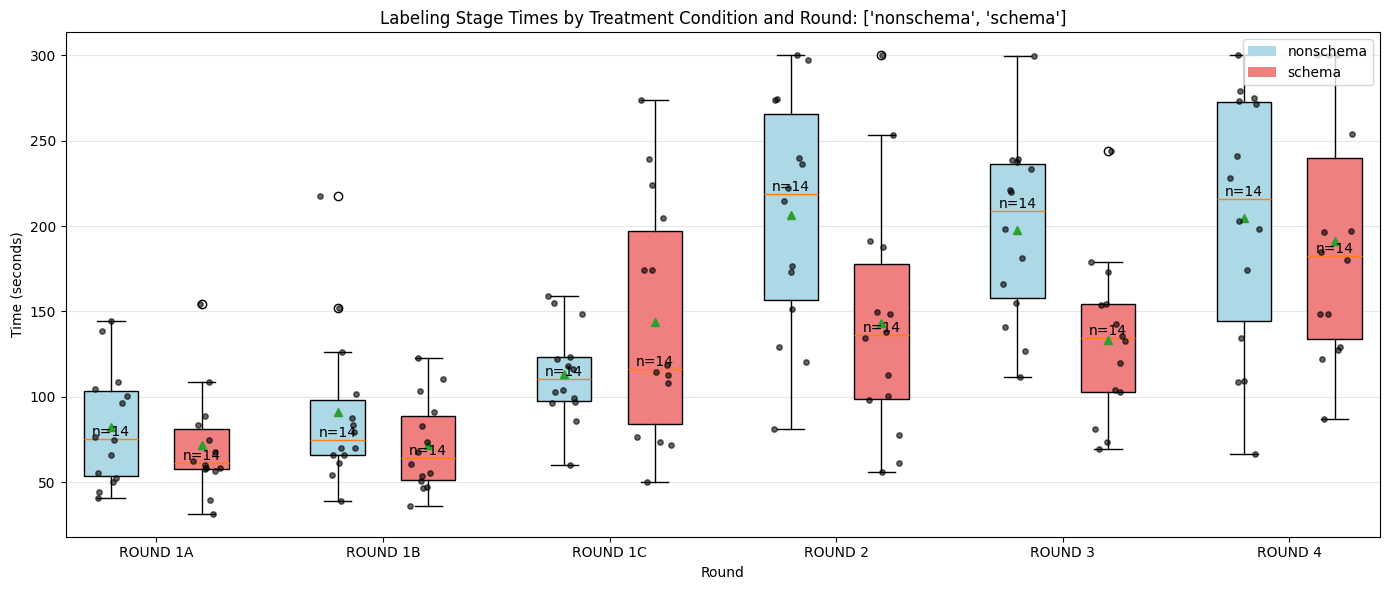

In [38]:
labeling_stage_time_cols = [col for col in data.columns if col.startswith("time_labeling_")]

use_conditions = ['nonschema', 'schema']

# Prepare data for box plot
# Melt the data to long format for easier plotting
plot_data = []
for col in labeling_stage_time_cols:
    for idx, row in data.iterrows():
        if row['treatment'] in use_conditions:
            plot_data.append({
                'round': col,
                'time': row[col],
                'condition': row['treatment']
            })

plot_df = pd.DataFrame(plot_data)

# Create the box plot
fig, ax = plt.subplots(figsize=(14, 6))

# Get unique rounds and conditions
rounds = labeling_stage_time_cols  # Use original column order
conditions = sorted(plot_df['condition'].unique())

def prettify_label(col_name):
    # Convert 'labeling_1a' to 'Round 1a', etc.
    return col_name.replace('time_labeling_', 'Round ').upper()

positions = []
labels = []
colors = []
color_map = {'nonschema': 'lightblue', 'schema': 'lightcoral'}

for i, round_name in enumerate(rounds):
    for j, condition in enumerate(conditions):
        positions.append(i * (len(conditions) + 0.5) + j)
        if j == 0:
            labels.append(prettify_label(round_name))
        colors.append(color_map.get(condition, 'gray'))

# Prepare data for each box
box_data = []
for round_name in rounds:
    for condition in conditions:
        data_subset = plot_df[(plot_df['round'] == round_name) & \
                              (plot_df['condition'] == condition)]['time'].dropna()
        box_data.append(data_subset)

# Create box plot
bp = ax.boxplot(box_data, positions=positions, widths=0.6, patch_artist=True,
                showmeans=True, meanline=False)

# Color the boxes
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

# Set x-axis labels
ax.set_xticks([i * (len(conditions) + 0.5) + 0.5 for i in range(len(rounds))])
ax.set_xticklabels([prettify_label(round_name) for round_name in rounds])

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color_map[cond], label=cond) 
                   for cond in conditions]
ax.legend(handles=legend_elements, loc='upper right')

# Labels and title
ax.set_xlabel('Round')
ax.set_ylabel('Time (seconds)')
ax.set_title(f'Labeling Stage Times by Treatment Condition and Round: {use_conditions}')
ax.grid(axis='y', alpha=0.3)

# Add n labels above each box
n_counts = plot_df.groupby(['round', 'condition']).count()['time']
for i, round_name in enumerate(rounds):
    for j, condition in enumerate(conditions):
        n = n_counts.get((round_name, condition), 0)
        pos = i * (len(conditions) + 0.5) + j
        y = box_data[i * len(conditions) + j].median() if len(box_data[i * len(conditions) + j]) > 0 else 0
        ax.text(pos, y, f'n={n}', ha='center', va='bottom', fontsize=10, color='black', rotation=0)

# add raw points
for i, round_name in enumerate(rounds):
    for j, condition in enumerate(conditions):
        pos = i * (len(conditions) + 0.5) + j
        data_subset = box_data[i * len(conditions) + j]
        # Add jittered scatter points
        x_jitter = np.random.uniform(-0.2, 0.2, size=len(data_subset))
        ax.scatter(np.full(len(data_subset), pos) + x_jitter, data_subset, 
                   alpha=0.6, color='black', s=15, zorder=3)

plt.tight_layout()
plt.show()

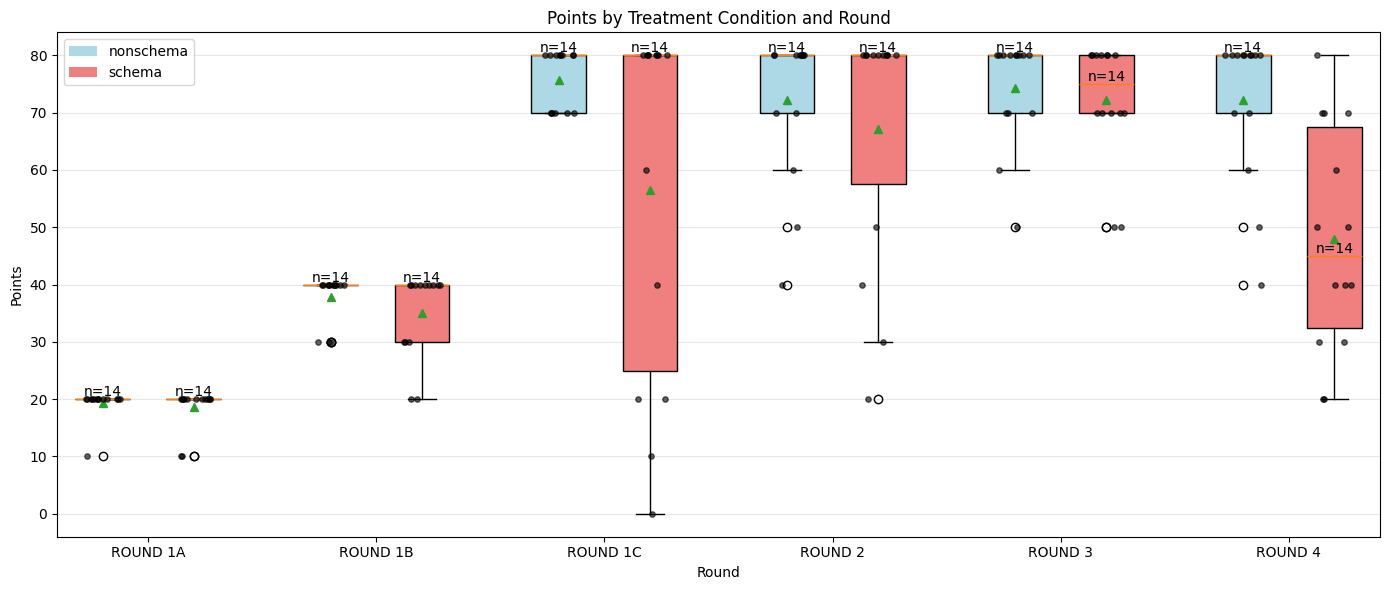

In [39]:
# Plot points by round instead of labeling time
points_cols = [col for col in data.columns if col.startswith("points_unique_")]

use_conditions = ['nonschema', 'schema']

# Prepare data for box plot
plot_data = []
for col in points_cols:
    for idx, row in data.iterrows():
        if row['treatment'] in use_conditions:
            plot_data.append({
                'round': col,
                'points': row[col],
                'condition': row['treatment']
            })

plot_df = pd.DataFrame(plot_data)

# Create the box plot
fig, ax = plt.subplots(figsize=(14, 6))

# Get unique rounds and conditions
rounds = points_cols  # Use original column order
conditions = sorted(plot_df['condition'].unique())

def prettify_label(col_name):
    # Convert 'points_1a' to 'Round 1a', etc.
    return col_name.replace('points_unique_', 'Round ').upper()

positions = []
labels = []
colors = []
color_map = {'nonschema': 'lightblue', 'schema': 'lightcoral'}

for i, round_name in enumerate(rounds):
    for j, condition in enumerate(conditions):
        positions.append(i * (len(conditions) + 0.5) + j)
        if j == 0:
            labels.append(prettify_label(round_name))
        colors.append(color_map.get(condition, 'gray'))

# Prepare data for each box
box_data = []
for round_name in rounds:
    for condition in conditions:
        data_subset = plot_df[(plot_df['round'] == round_name) & \
                              (plot_df['condition'] == condition)]['points'].dropna()
        box_data.append(data_subset)

# Create box plot
bp = ax.boxplot(box_data, positions=positions, widths=0.6, patch_artist=True,
                showmeans=True, meanline=False)

# Color the boxes
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

# Set x-axis labels
ax.set_xticks([i * (len(conditions) + 0.5) + 0.5 for i in range(len(rounds))])
ax.set_xticklabels([prettify_label(round_name) for round_name in rounds])

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color_map[cond], label=cond) 
                   for cond in conditions]
ax.legend(handles=legend_elements, loc='upper left')

# Labels and title
ax.set_xlabel('Round')
ax.set_ylabel('Points')
ax.set_title('Points by Treatment Condition and Round')
ax.grid(axis='y', alpha=0.3)

# Add n labels above each box
n_counts = plot_df.groupby(['round', 'condition']).count()['points']
for i, round_name in enumerate(rounds):
    for j, condition in enumerate(conditions):
        n = n_counts.get((round_name, condition), 0)
        pos = i * (len(conditions) + 0.5) + j
        y = box_data[i * len(conditions) + j].median() if len(box_data[i * len(conditions) + j]) > 0 else 0
        ax.text(pos, y, f'n={n}', ha='center', va='bottom', fontsize=10, color='black', rotation=0)


# add raw points
for i, round_name in enumerate(rounds):
    for j, condition in enumerate(conditions):
        pos = i * (len(conditions) + 0.5) + j
        data_subset = box_data[i * len(conditions) + j]
        # Add jittered scatter points
        x_jitter = np.random.uniform(-0.2, 0.2, size=len(data_subset))
        ax.scatter(np.full(len(data_subset), pos) + x_jitter, data_subset, 
                   alpha=0.6, color='black', s=15, zorder=3)

plt.tight_layout()
plt.show()

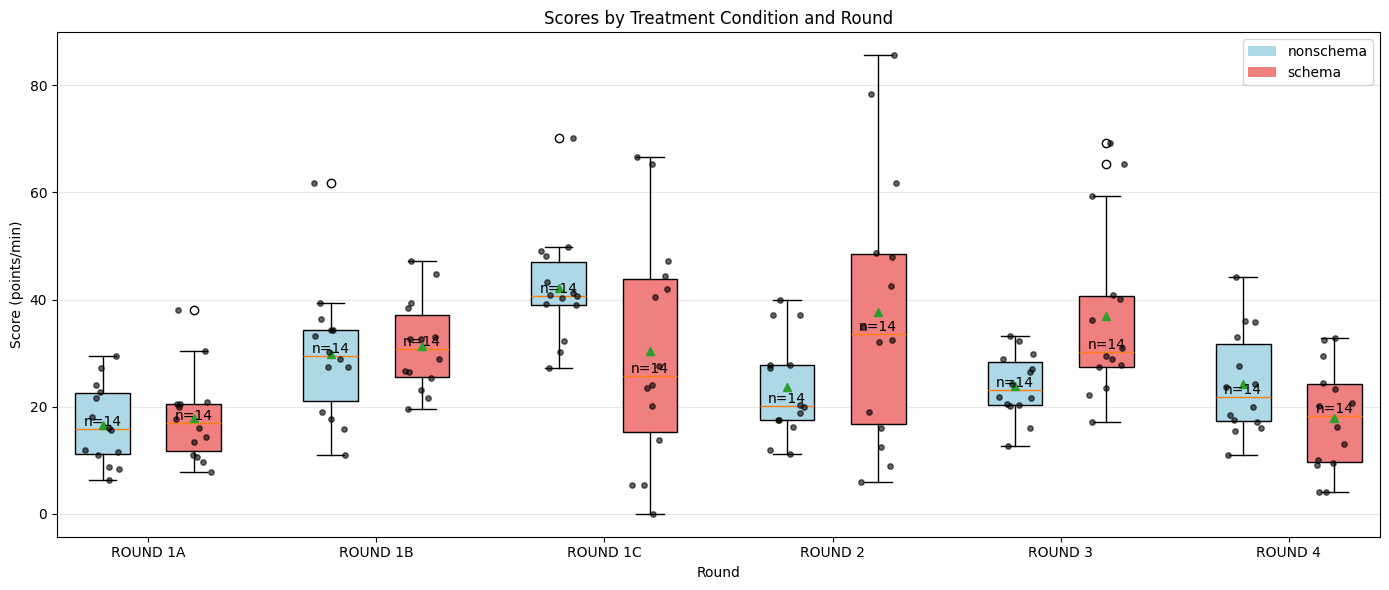

In [42]:
# Plot scores by round instead of labeling time
score_cols = [col for col in data.columns if col.startswith('score_')]
use_conditions = ['nonschema', 'schema']



# Prepare data for box plot
plot_data = []
for col in score_cols:
    for idx, row in data.iterrows():
        if row['treatment'] in use_conditions:
            plot_data.append({
                'round': col,
                'score': row[col],
                'condition': row['treatment']
            })

plot_df = pd.DataFrame(plot_data)

# Create the box plot
fig, ax = plt.subplots(figsize=(14, 6))

# Get unique rounds and conditions
rounds = score_cols  # Use original column order
conditions = sorted(plot_df['condition'].unique())

def prettify_label(col_name):
    # Convert 'score_1a' to 'Round 1a', etc.
    return col_name.replace('score_', 'Round ').upper()

positions = []
labels = []
colors = []
color_map = {'nonschema': 'lightblue', 'schema': 'lightcoral'}

for i, round_name in enumerate(rounds):
    for j, condition in enumerate(conditions):
        positions.append(i * (len(conditions) + 0.5) + j)
        if j == 0:
            labels.append(prettify_label(round_name))
        colors.append(color_map.get(condition, 'gray'))

box_data = []
for round_name in rounds:
    for condition in conditions:
        data_subset = plot_df[(plot_df['round'] == round_name) & \
                              (plot_df['condition'] == condition)]['score'].dropna()
        box_data.append(data_subset)

bp = ax.boxplot(box_data, positions=positions, widths=0.6, patch_artist=True,
                showmeans=True, meanline=False)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax.set_xticks([i * (len(conditions) + 0.5) + 0.5 for i in range(len(rounds))])
ax.set_xticklabels([prettify_label(round_name) for round_name in rounds])

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color_map[cond], label=cond) 
                   for cond in conditions]
ax.legend(handles=legend_elements, loc='upper right')

ax.set_xlabel('Round')
ax.set_ylabel('Score (points/min)')
ax.set_title('Scores by Treatment Condition and Round')
ax.grid(axis='y', alpha=0.3)

# Add n labels above each box
n_counts = plot_df.groupby(['round', 'condition']).count()['score']
for i, round_name in enumerate(rounds):
    for j, condition in enumerate(conditions):
        n = n_counts.get((round_name, condition), 0)
        pos = i * (len(conditions) + 0.5) + j
        y = box_data[i * len(conditions) + j].median() if len(box_data[i * len(conditions) + j]) > 0 else 0
        ax.text(pos, y, f'n={n}', ha='center', va='bottom', fontsize=10, color='black', rotation=0)

# add raw points
for i, round_name in enumerate(rounds):
    for j, condition in enumerate(conditions):
        pos = i * (len(conditions) + 0.5) + j
        data_subset = box_data[i * len(conditions) + j]
        # Add jittered scatter points
        x_jitter = np.random.uniform(-0.2, 0.2, size=len(data_subset))
        ax.scatter(np.full(len(data_subset), pos) + x_jitter, data_subset, 
                   alpha=0.6, color='black', s=15, zorder=3)


plt.tight_layout()
plt.show()

In [41]:
# perform t-tests on times and points between conditions for each round
from scipy import stats
for round in ['1a', '1b', '1c', '2', '3', '4']:
    time_col = f'time_labeling_{round}'
    points_col = f'points_unique_{round}'
    
    group1 = data[data['treatment'] == 'nonschema']
    group2 = data[data['treatment'] == 'schema']
    
    t_stat_time, p_val_time = stats.ttest_ind(group1[time_col], group2[time_col], equal_var=False)
    t_stat_points, p_val_points = stats.ttest_ind(group1[points_col], group2[points_col], equal_var=False)
    
    print(f'Round {round}:')
    print(f'  Time - t-statistic: {t_stat_time:.4f}, p-value: {p_val_time:.4f}')
    print(f'  Points - t-statistic: {t_stat_points:.4f}, p-value: {p_val_points:.4f}\n')

Round 1a:
  Time - t-statistic: 0.8785, p-value: 0.3878
  Points - t-statistic: 0.5927, p-value: 0.5589

Round 1b:
  Time - t-statistic: 1.3411, p-value: 0.1944
  Points - t-statistic: 1.2277, p-value: 0.2335

Round 1c:
  Time - t-statistic: -1.5093, p-value: 0.1498
  Points - t-statistic: 2.2763, p-value: 0.0394

Round 2:
  Time - t-statistic: 2.3846, p-value: 0.0247
  Points - t-statistic: 0.7307, p-value: 0.4729

Round 3:
  Time - t-statistic: 3.3996, p-value: 0.0022
  Points - t-statistic: 0.5693, p-value: 0.5741

Round 4:
  Time - t-statistic: 0.4800, p-value: 0.6352
  Points - t-statistic: 3.8422, p-value: 0.0009



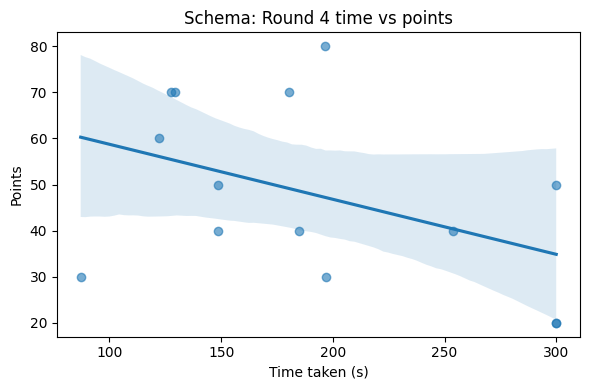

In [57]:
import seaborn as sns

df = data[data["treatment"] == "schema"]

plt.figure(figsize=(6,4))
sns.regplot(
    data=df,
    x="time_labeling_4",
    y="points_unique_4",
    ci=95,
    scatter_kws={"alpha": 0.6}
)
plt.xlabel("Time taken (s)")
plt.ylabel("Points")
plt.title("Schema: Round 4 time vs points")
plt.tight_layout()

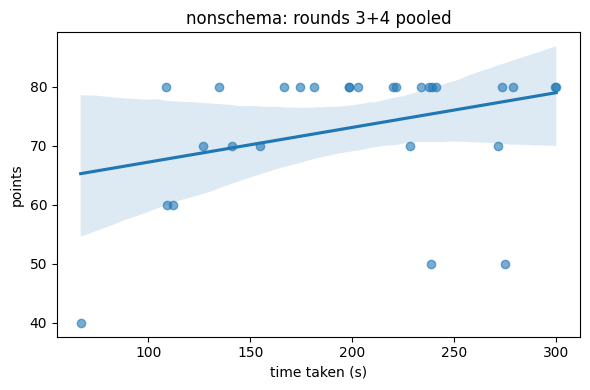

In [60]:
use_treatment =  "nonschema" # None # "schema"  # or "nonschema"; set to None for both

rounds = ["3", "4"]
plot_df = pd.concat(
    [
        data[["treatment", f"time_labeling_{r}", f"points_unique_{r}"]]
        .rename(columns={
            f"time_labeling_{r}": "time",
            f"points_unique_{r}": "points",
        })
        .assign(round=r)
        for r in rounds
    ],
    ignore_index=True,
)

if use_treatment is not None:
    plot_df = plot_df[plot_df["treatment"] == use_treatment]

plt.figure(figsize=(6,4))
sns.regplot(
    data=plot_df,
    x="time",
    y="points",
    ci=95,
    scatter_kws={"alpha": 0.6}
)
plt.xlabel("time taken (s)")
plt.ylabel("points")
plt.title(f"{use_treatment or 'all'}: rounds 3+4 pooled")
plt.tight_layout()


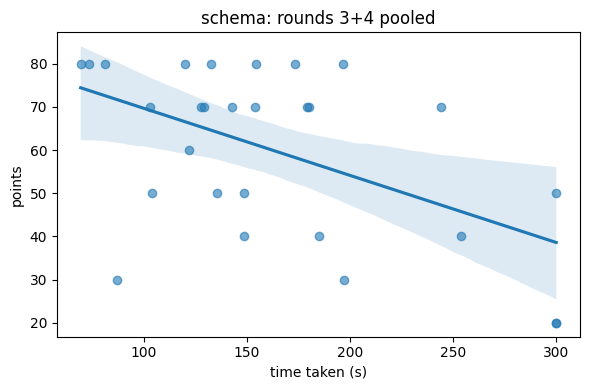

In [62]:
use_treatment =  "schema" # None # "schema"  # or "nonschema"; set to None for both

rounds = ["3", "4"]
plot_df = pd.concat(
    [
        data[["treatment", f"time_labeling_{r}", f"points_unique_{r}"]]
        .rename(columns={
            f"time_labeling_{r}": "time",
            f"points_unique_{r}": "points",
        })
        .assign(round=r)
        for r in rounds
    ],
    ignore_index=True,
)

if use_treatment is not None:
    plot_df = plot_df[plot_df["treatment"] == use_treatment]

plt.figure(figsize=(6,4))
sns.regplot(
    data=plot_df,
    x="time",
    y="points",
    ci=95,
    scatter_kws={"alpha": 0.6}
)
plt.xlabel("time taken (s)")
plt.ylabel("points")
plt.title(f"{use_treatment or 'all'}: rounds 3+4 pooled")
plt.tight_layout()

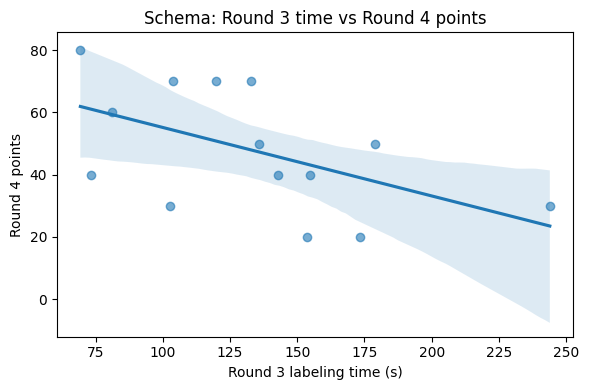

In [ ]:
# does being faster in round 3 (presumably more schematization?) hurt you in round 4?
df = data[data["treatment"] == "schema"][["time_labeling_3", "points_unique_4"]].dropna()

plt.figure(figsize=(6,4))
sns.regplot(
    data=df,
    x="time_labeling_3",
    y="points_unique_4",
    ci=95,
    scatter_kws={"alpha": 0.6}
)
plt.xlabel("Round 3 labeling time (s)")
plt.ylabel("Round 4 points")
plt.title("Schema: Round 3 time vs Round 4 points")
plt.tight_layout()
